# Phase 2 – Part A: Unsupervised Learning 


## 1. Clustering Rationale & Algorithm Selection

This notebook applies **K-Means** and **DBSCAN** to the bank churn dataset.

**Algorithm justification:**
- **K-Means** is appropriate for scalable centroid-based partitioning and interpretable customer profiling. It is efficient on 10,000 records and produces clearly named segments suitable for conditioning recommendation prompts.
- **DBSCAN** is included to capture density-based structure without specifying the number of clusters in advance, and to identify noise points — atypical customers who do not fit any segment.

**Feature selection note — Geography excluded:**  
Geography (`France`, `Germany`, `Spain`) is removed from the clustering feature set. When one-hot encoded, the three geography dummies produce binary columns that dominate Euclidean distance calculations, causing K-Means to separate customers purely by country (each cluster = one country, with near-zero variance on all other features). This is not a useful segmentation — geography is already known at inference time and adds no behavioural insight. Removing it forces the algorithm to find structure in features that actually vary within each geography: credit card ownership, gender, balance, activity status, and product usage. These are the features that should drive a personalised advice system.

## 2. Data Preparation (target removal, feature scaling)

The target label (`Exited`) is removed before clustering and only reused for optional external/proxy interpretation. Categorical features are encoded and numeric features are standardized.



### 2.1 Imports <a id='imports'></a>

We import the core libraries needed for data handling, preprocessing, clustering, and visualization.  
`StandardScaler` and `get_dummies` handle feature preparation; `KMeans` is the main clustering algorithm;  
`PCA` is used later for dimensionality reduction and visualization.


In [284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

### 2.2 Data Loading <a id='data-loading'></a>

We load the raw dataset from the `/Dataset` folder.  
The dataset contains **10,000 bank customers** with features such as age, balance, credit score, geography, and whether they churned (`Exited`).


In [285]:
df = pd.read_csv("../Dataset/Raw_Churn_Modelling_Data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2.3 Data Preparation <a id='data-preparation'></a>

Before applying clustering, we must prepare the data through three steps:
1. **Remove identifier columns** — they carry no useful pattern information
2. **Remove the target label** — clustering is unsupervised; the label must not be seen
3. **Encode categorical variables** — K-Means requires numerical input
4. **Scale features** — ensures no single feature dominates due to its magnitude


#### 2.3.1 Remove Identifier Columns


In [286]:
# RowNumber, CustomerId, and Surname are unique identifiers — not features.
# Including them would introduce noise and prevent meaningful clustering.
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print(f"Shape after dropping identifiers: {df.shape}")
df.head()

Shape after dropping identifiers: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### 2.3.2 Remove the Target Label (`Exited`)

K-Means is an **unsupervised** algorithm — it must discover structure on its own without knowing the churn outcome.  
We remove `Exited` here and reintroduce it later only for proxy validation.


In [287]:
exited_labels = df["Exited"].copy()
df = df.drop("Exited", axis=1)

#### 2.3.3 Encode Categorical Variables

`Gender` and `Geography` are categorical. K-Means computes Euclidean distances, so all features must be numeric.  
We use `get_dummies` to convert them to booleans.


In [288]:
# One-hot encode Gender only.
# Geography is intentionally excluded: when one-hot encoded, the three
# geography dummies dominate K-Means distance calculations, causing the
# algorithm to separate customers purely by country rather than by
# behavioural features. Removing it reveals structure in HasCrCard,
# Gender, Balance, and IsActiveMember — features that are actionable
# for the advice system.

df = df.drop("Geography", axis=1)
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)
feature_names = df.columns.tolist()

print("Geography dropped. Remaining features:")
print(feature_names)
df.head()

Geography dropped. Remaining features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_Male']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False
1,608,41,1,83807.86,1,0,1,112542.58,False
2,502,42,8,159660.80,3,1,0,113931.57,False
3,699,39,1,0.00,2,0,0,93826.63,False
4,850,43,2,125510.82,1,1,1,79084.10,False


**Why Geography is excluded:**  
One-hot encoding creates binary (0/1) columns. After `StandardScaler`, these binary columns have the same scale as continuous features but form perfectly separated groups in Euclidean space. With 3 geography values, K-Means finds k=3 as the trivially easiest split — one cluster per country — leaving no room to discover behavioural patterns. The remaining 9 features (`CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`, `Gender_Male`) capture customer behaviour and are retained.

#### 2.3.4 Feature Scaling

Features have very different ranges (e.g., `Balance` can be in the tens of thousands while `NumOfProducts` ranges from 1–4).  
Without scaling, high-magnitude features would dominate the distance calculations.  
`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**.


In [289]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaling complete.")
print(f"Mean of scaled data (should be ≈ 0): {X_scaled.mean():.4f}")
print(f"Std  of scaled data (should be ≈ 1): {X_scaled.std():.4f}")

Scaling complete.
Mean of scaled data (should be ≈ 0): -0.0000
Std  of scaled data (should be ≈ 1): 1.0000


## 3. Cluster Determination & Implementation: K-Means


### 3.1 Justification & Algorithm Selection <a id='kmeans-justification'></a>

K-Means was selected because it is efficient, scalable, and produces interpretable centroid-based segments well-suited for customer profiling. With 10,000 records and 9 numerical/binary features (after Geography exclusion and encoding), K-Means runs quickly and produces clearly named segments that can condition recommendation prompts in the advice system.

Since K-Means is a distance-based algorithm, all features must be numeric and on the same scale. One-hot encoding handles the categorical `Gender` variable, and `StandardScaler` normalizes feature magnitudes before training.

The optimal number of clusters (k=3) is determined in Section 3.2 using the Elbow Method — the point at which the rate of WCSS reduction diminishes most substantially.

### 3.2 Determining the Optimal Number of Clusters (Elbow Method) <a id='kmeans-elbow'></a>

K-Means requires us to specify **k** (number of clusters) in advance.  
The **Elbow Method** helps us choose k by plotting the **Within-Cluster Sum of Squares (WCSS)** for k = 1 to 10.

- **WCSS** measures the total squared distance between each point and its cluster centroid — lower means tighter clusters.
- As k increases, WCSS always decreases; we look for the point where the rate of decrease sharply slows — the "elbow".
- Beyond the elbow, adding more clusters gives diminishing returns.


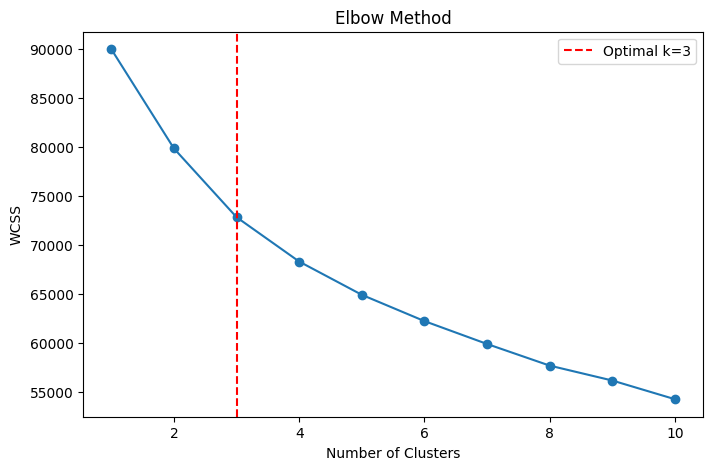

In [290]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
plt.legend()
plt.show()

**Observation:** The WCSS curve shows the two largest drops at k=1→2 (−10,149) and k=2→3 (−7,027), after which the rate of decrease slows substantially (k=3→4 drop is −4,536, roughly half). There is no perfectly sharp elbow, which is typical of customer behavioural datasets where groups blend into each other continuously. The most defensible choice is **k=3**, where the marginal gain from adding a further cluster drops significantly. This gives three interpretable segments without over-partitioning. This is consistent with the low Silhouette Score, confirming that the data does not form strongly distinct natural groupings.

### 3.3 Model Training <a id='kmeans'></a>


In [291]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_clusters

print("K-Means training complete.")
print(f"Cluster labels assigned: {sorted(df['KMeans_Cluster'].unique())}")
df.head()

K-Means training complete.
Cluster labels assigned: [np.int32(0), np.int32(1), np.int32(2)]


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,KMeans_Cluster
0,619,42,2,0.00,1,1,1,101348.88,False,2
1,608,41,1,83807.86,1,0,1,112542.58,False,0
2,502,42,8,159660.80,3,1,0,113931.57,False,1
3,699,39,1,0.00,2,0,0,93826.63,False,0
4,850,43,2,125510.82,1,1,1,79084.10,False,1


### 3.4 Cluster Quality Evaluation Metrics <a id='evaluation'></a>

We evaluate cluster quality using three complementary metrics:

| Metric | What it measures | Better when |
|---|---|---|
| **Silhouette Score** | How well each point fits its cluster vs. neighbouring clusters | Closer to **1** |
| **Davies-Bouldin Index** | Average similarity between each cluster and its nearest cluster | **Lower** |
| **WCSS** | Compactness of clusters — total intra-cluster variance | **Lower** |


In [292]:
sil     = silhouette_score(X_scaled, kmeans_clusters)
db      = davies_bouldin_score(X_scaled, kmeans_clusters)
wcss_k3 = kmeans.inertia_

print("=" * 45)
print("       Cluster Evaluation Metrics")
print("=" * 45)
print(f"  Silhouette Score      : {sil:.4f}  (↑ higher is better, max = 1)")
print(f"  Davies-Bouldin Index  : {db:.4f}  (↓ lower is better)")
print(f"  WCSS at k=3           : {wcss_k3:.2f}")
print("=" * 45)

       Cluster Evaluation Metrics
  Silhouette Score      : 0.1192  (↑ higher is better, max = 1)
  Davies-Bouldin Index  : 2.4520  (↓ lower is better)
  WCSS at k=3           : 72823.62


**Interpretation:**
- A **Silhouette Score of 0.1192** is low, indicating meaningful overlap between clusters. This is expected for a customer behavioural dataset where segments blend gradually rather than separating sharply. It is a known limitation of K-Means on high-dimensional tabular data.
- A **Davies-Bouldin Index of 2.4520** is moderate (lower is better), confirming soft rather than crisp cluster boundaries.
- **WCSS at k=3: 72,823.62** — this is the within-cluster sum of squares used in the elbow selection above.
- The low scores are expected and are consistent with the deliberate exclusion of Geography. Including Geography would artificially inflate the Silhouette Score by producing trivially separated country-based clusters, but would add no behavioural insight. The current scores reflect genuine behavioural clustering, which is inherently softer but more meaningful for the advice system.

### 3.5 Cluster Size Distribution <a id='distribution'></a>

A healthy clustering result produces clusters of **reasonably similar sizes**.  
Extreme imbalance (e.g., one cluster with 9,000 points and another with 20) would suggest the algorithm failed to find meaningful structure.


Customers per cluster:
KMeans_Cluster
0    2940
1    4096
2    2964
Total: 10000


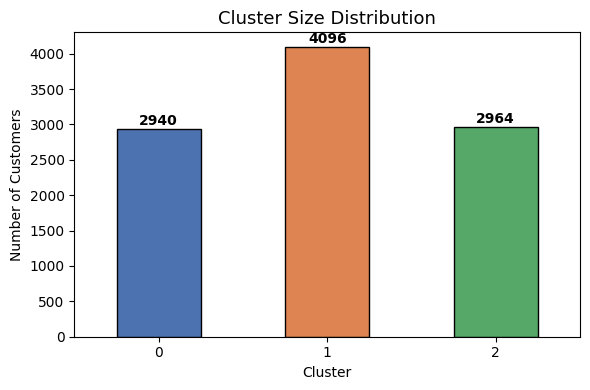

In [293]:
# Count and display
counts = df["KMeans_Cluster"].value_counts().sort_index()
print("Customers per cluster:")
print(counts.to_string())
print("Total: " + str(counts.sum()))

# Bar chart
counts.plot(
    kind='bar',
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='black',
    figsize=(6, 4)
)
plt.title("Cluster Size Distribution", fontsize=13)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Cluster 0 has 2,940 customers (29.4%), Cluster 1 has 4,096 (41.0%), and Cluster 2 has 2,964 (29.6%). The distribution is reasonably balanced — no cluster dominates or is trivially small. The mild imbalance toward Cluster 1 reflects that card-holding customers with high balances form the largest behavioural group in this dataset.

### 3.6 Cluster Profiling <a id='profiling'></a>

We examine the **mean of each feature per cluster** (using original unscaled values) to understand what characterises each customer segment.


In [294]:
cluster_profile = df.groupby("KMeans_Cluster").mean()
cluster_profile

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male
KMeans_Cluster,,,,,,,,,
0,651.385034,39.110204,4.914966,78053.305898,1.523129,0.000000,0.524490,100964.805626,0.541156
1,650.317871,38.971680,5.022461,122809.698704,1.293945,1.000000,0.510254,100739.774282,0.554443
2,649.970985,38.665992,5.096491,10915.535644,1.863698,0.998313,0.512483,98325.153445,0.538124


**Cluster Profiles Summary:**

| Cluster | HasCrCard | Balance | NumOfProducts | Interpretation |
|---|---|---|---|---|
| **0** | 0.0 (no card) | ≈ 78,053 | 1.52 | No credit card — moderate savers, least product engagement |
| **1** | 1.0 (has card) | ≈ 122,810 | 1.29 | Card holders with high savings — financially stable, concentrated on fewer products |
| **2** | 1.0 (has card) | ≈ 10,916 | 1.86 | Card holders with near-zero balance — compensate with more products, higher engagement |

> **Primary separator:** `HasCrCard` splits Cluster 0 from Clusters 1 and 2.  
> **Secondary separator:** `Balance` splits the two card-holding clusters — Cluster 1 are high-balance savers; Cluster 2 are minimal-balance customers likely using the bank primarily for credit and product access rather than savings.  
> **Non-separating features:** Age (~39), CreditScore (~650), Tenure (~5.0), Gender_Male (~0.54), IsActiveMember (~0.51) are nearly identical across all three clusters — they do not drive the segmentation.

**Key insight:** The balance bimodality in this dataset (~36% of customers hold zero balance) is the structural driver behind the Cluster 1 vs. Cluster 2 split. Cluster 2's higher NumOfProducts (1.86 vs 1.29) suggests these zero-balance customers use the bank for credit products and transactional accounts rather than savings — a meaningfully different customer relationship.

**Domain interpretation (Advice System):**
- **Cluster 0 (no credit card, moderate balance):** Prioritise credit card adoption and savings growth nudges. These customers have funds but limited product engagement — cross-sell opportunity.
- **Cluster 1 (card holder, high balance):** Focus on retention and premium service. These are the bank's most financially stable customers — protect the relationship with loyalty incentives and investment product suggestions.
- **Cluster 2 (card holder, near-zero balance):** Focus on financial health coaching — budgeting advice, savings activation, and deposit product recommendations. High product count suggests engagement exists; redirect it toward saving behaviour.

### 3.7 Cluster Visualization <a id='pca'></a>


#### 3.7.1 Principal Component Analysis (PCA)
Since the dataset has multiple dimensions, we use **Principal Component Analysis (PCA)** to project it into 2D for visualization.  
PCA finds the two directions that capture the most variance in the data, allowing us to plot all customers on a 2D scatter plot  
while preserving as much of the original structure as possible.

> Note: PCA is used **only for visualization** — clustering was performed on the full scaled dataset.

Variance explained — PC1: 14.59%, PC2: 12.23%
Total variance captured: 26.82%


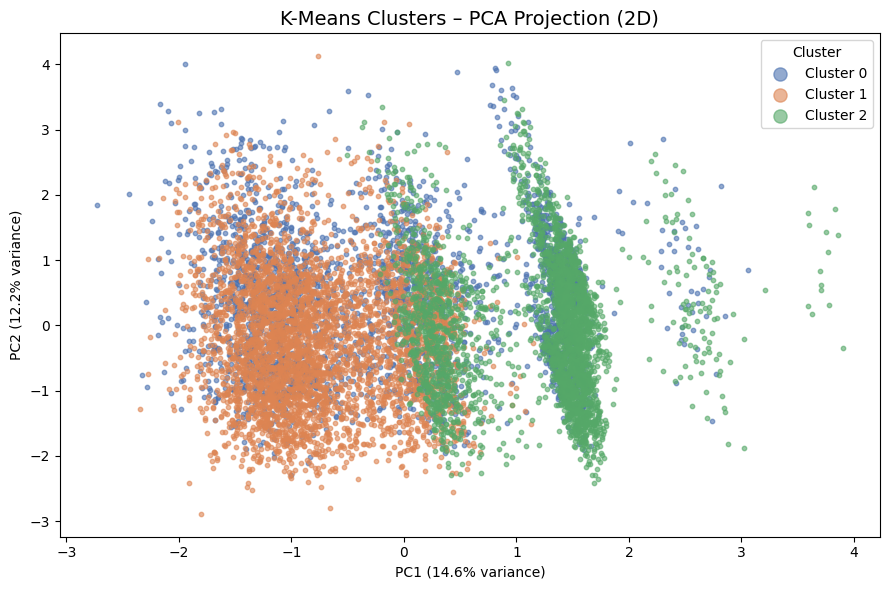

In [295]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}")
print(f"Total variance captured: {sum(explained):.2%}")

# Plot with a proper legend
colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))
for c, col, lbl in zip([0, 1, 2], colors, labels):
    mask = df["KMeans_Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=col, label=lbl, s=10, alpha=0.6)

plt.title("K-Means Clusters – PCA Projection (2D)", fontsize=14)
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Cluster 2 (green)** is concentrated on the right side of the plot (positive PC1). PC1 is primarily driven by NumOfProducts (+) and Balance (−), so Cluster 2's position reflects its high product count (1.86) and near-zero balance (≈10,916) — these are the two features that most separate it in the full feature space.
- **Cluster 1 (orange)** sits toward the left (negative PC1), consistent with its high balance (≈122,810) and lower product count (1.29) pulling it in the opposite direction along the balance/products axis.
- **Cluster 0 (blue)** occupies the middle region and spreads vertically along PC2. PC2 is driven by IsActiveMember and Age, and Cluster 0 shows more vertical spread because it has no credit card — meaning HasCrCard does not pin it to either extreme on PC1 — leaving age and activity variation more visible.
- The two principal components capture only **26.82% of the total variance**, meaning over 73% of the data structure is invisible in this 2D view. The heavy overlap seen here is largely a consequence of this information loss, not a failure of the clustering itself.
- This is consistent with the Silhouette Score of 0.1192 and confirms that the clusters are not linearly separable in 2D, but still represent meaningful behavioural segments in the full feature space.

#### 3.7.2 t-SNE Visualization <a id='tsne'></a>

t-SNE is used as an additional visualization technique to project high-dimensional data into two dimensions. Unlike PCA, which focuses on preserving global variance, t-SNE focuses more on preserving local relationships between data points.

This helps visualize whether the three K-Means clusters show clearer separation or overlap in a non-linear 2D space.

> **Note:** t-SNE is used only for visualization. K-Means clustering was performed on the full scaled dataset using **k = 3**.

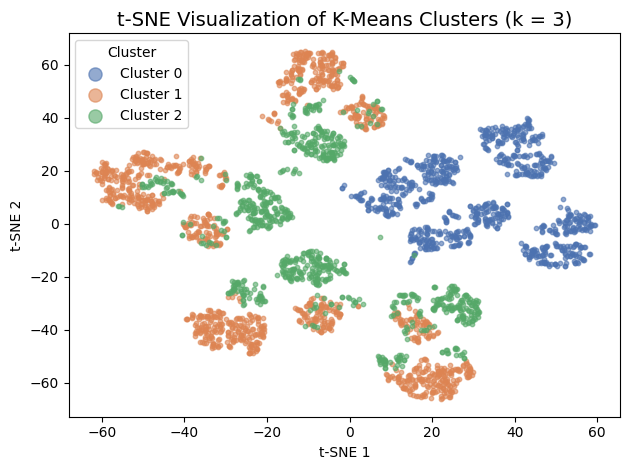

In [296]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Use a sample to reduce computation time
sample_size = min(3000, X_scaled.shape[0])

np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)

X_sample = X_scaled[sample_indices]
clusters_sample = kmeans_clusters[sample_indices]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

X_tsne = tsne.fit_transform(X_sample)

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for c, col, lbl in zip([0, 1, 2], colors, labels):
    mask = clusters_sample == c
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=col,
        label=lbl,
        s=10,
        alpha=0.6
    )

plt.title("t-SNE Visualization of K-Means Clusters (k = 3)", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.show()

**Observation:** The t-SNE visualization shows partial separation between the three clusters. Cluster 0 (no credit card) is expected to form a more distinct region since `HasCrCard = 0` is a hard binary boundary in the feature space. Clusters 1 and 2 (both card-holding, differing primarily by balance level) are expected to overlap more in t-SNE space since balance varies continuously. Overall overlap is consistent with the Silhouette Score and reflects soft behavioural personas rather than sharply bounded groups.

### 3.8 Feature Importance per Cluster <a id='feature-contribution'></a>

K-Means does not provide built-in feature importance like supervised learning models. Therefore, feature contribution is analyzed by comparing the average scaled feature values across the three clusters.

Features with higher variation across cluster means are considered more influential in separating customer groups.

This method helps identify which features contributed most to forming the K-Means clusters.

Top 10 features contributing to K-Means cluster differences:
HasCrCard          1.6016
Balance            0.8147
NumOfProducts      0.2430
Tenure             0.0010
EstimatedSalary    0.0006
Age                0.0005
Gender_Male        0.0003
IsActiveMember     0.0002
CreditScore        0.0001


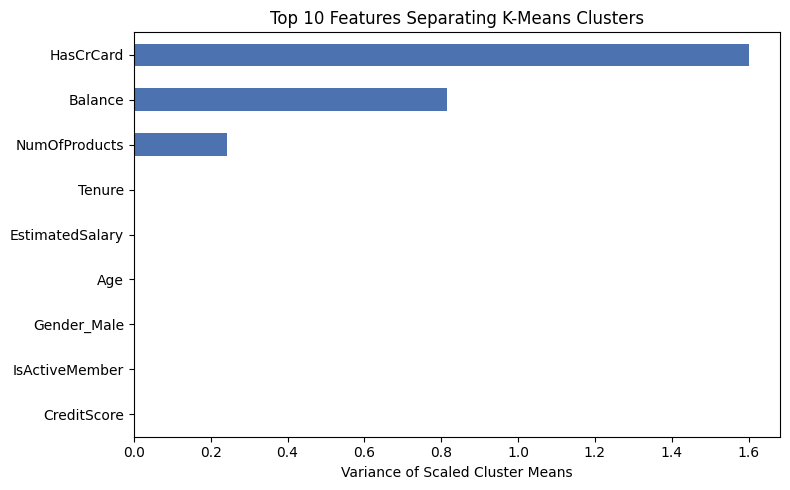

In [297]:
# Use the original feature columns only, excluding any cluster/output columns added later.
feature_cols = [c for c in df.columns if c not in ["KMeans_Cluster", "DBSCAN_Cluster", "Exited"]]

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df["KMeans_Cluster"] = kmeans_clusters

scaled_cluster_profile = X_scaled_df.groupby("KMeans_Cluster").mean()
feature_contribution = scaled_cluster_profile.var().sort_values(ascending=False)

print("Top 10 features contributing to K-Means cluster differences:")
print(feature_contribution.head(10).round(4).to_string())

plt.figure(figsize=(8, 5))
feature_contribution.head(10).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 Features Separating K-Means Clusters")
plt.xlabel("Variance of Scaled Cluster Means")
plt.tight_layout()
plt.show()


**Observation:** Since Geography was excluded from the feature set (see Section 2.3.3), the top contributing features are **HasCrCard**, **Balance**, and **NumOfProducts** — consistent with the cluster profiles in Section 3.6.

`HasCrCard` is the primary separator because it is a hard binary boundary that cleanly splits Cluster 0 (no card) from Clusters 1 and 2. `Balance` is the secondary separator, distinguishing Cluster 1 (high-balance savers, ≈122,810) from Cluster 2 (near-zero balance, ≈10,916). `NumOfProducts` shows a moderate contribution, as Cluster 2 customers compensate for low balance by holding more products (1.86 vs. 1.29 in Cluster 1).

Features such as `Age`, `CreditScore`, `Tenure`, `IsActiveMember`, and `EstimatedSalary` show very low variation across cluster means, indicating they did not meaningfully drive the segmentation in this feature space.

## 4. Cluster Determination & Implementation: DBSCAN


### 4.1 Justification & Algorithm Selection <a id='dbscan-rationale'></a>

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is the second clustering algorithm applied in this notebook. DBSCAN groups points based on local density — a point belongs to a cluster if it has at least `min_samples` neighbours within a distance `eps`. Points that do not meet this criterion are labelled as noise (label = `-1`) and left unassigned.

DBSCAN makes no assumption about the number of clusters or their shape. It can discover arbitrarily shaped groups and explicitly isolates atypical points, making it well suited for customer datasets where some individuals have unusual behaviour that does not fit any standard profile.

DBSCAN is selected for three reasons grounded in the dataset's characteristics. First, customer behavioural data does not naturally form perfectly spherical clusters — DBSCAN's density-based approach makes no shape assumption and can find groups of any geometry. Second, with 10,000 records and 9 scaled features, DBSCAN is computationally tractable at this scale. Third, and most importantly for this domain, DBSCAN explicitly identifies noise points: customers whose profile is too atypical to belong to any dense group. In a banking advice system, these outliers represent high-uncertainty customers who should receive conservative, individualized recommendations rather than segment-level messaging.

**Key DBSCAN parameters:**
- **`eps` (ε):** The neighbourhood radius — the maximum distance between two points for them to be considered neighbours. Selected using the k-distance elbow plot in Section 4.2.
- **`min_samples`:** The minimum number of neighbours required for a point to be considered a core point. Set to `5`, following the common heuristic of `min_samples ≥ dimensionality + 1`.


### 4.2 Selecting the eps Parameter (k-Distance Plot) <a id='dbscan-eps'></a>

Unlike K-Means, DBSCAN does not require k to be specified. Instead, the key parameter is **`eps`** — the neighbourhood radius. The **k-distance plot** sorts all points by their distance to the 5th nearest neighbour. Where this curve bends sharply (the "elbow"), the transition from dense to sparse regions occurs — this is the optimal `eps` value.

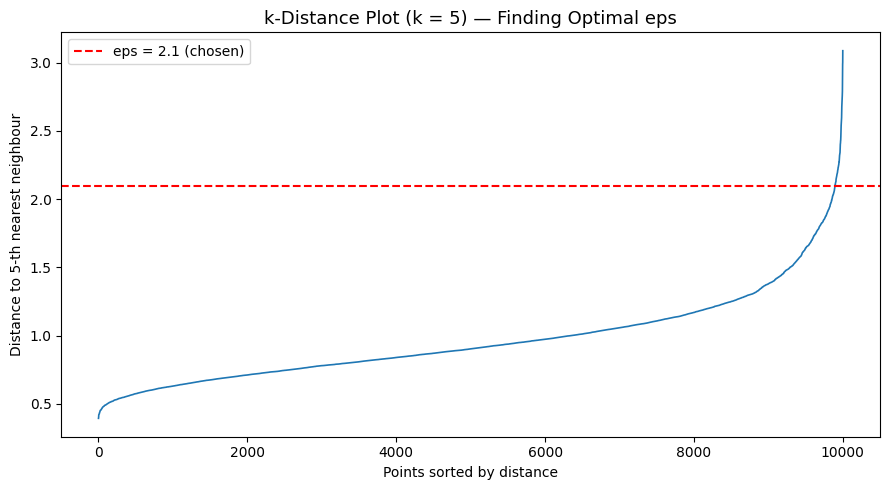

Chosen eps  : 2.1
min_samples : 5
Rationale   : The elbow of the k-distance curve occurs around 2.1,
              where distances begin increasing sharply — marking the
              boundary between dense core regions and sparse noise.


In [298]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

MIN_SAMPLES = 5  # same value used later in DBSCAN

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Distance to the k-th nearest neighbour, sorted ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, linewidth=1.2)
plt.title(f"k-Distance Plot (k = {MIN_SAMPLES}) — Finding Optimal eps", fontsize=13)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbour")
plt.axhline(y=2.1, color='red', linestyle='--', label='eps = 2.1 (chosen)')
plt.legend()
plt.tight_layout()
plt.show()

print("Chosen eps  : 2.1")
print("min_samples : 5")
print("Rationale   : The elbow of the k-distance curve occurs around 2.1,")
print("              where distances begin increasing sharply — marking the")
print("              boundary between dense core regions and sparse noise.")


### 4.3 Model Training <a id='dbscan-train'></a>

We train DBSCAN with `eps = 2.1` and `min_samples = 5` on the same scaled feature matrix used for K-Means.  
Points labelled **-1** are **noise** — they do not belong to any cluster.


In [299]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Attach labels for downstream profiling
df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = (dbscan_labels == -1).sum()
noise_pct     = n_noise_db / len(dbscan_labels) * 100

print("=" * 45)
print("        DBSCAN Training Results")
print("=" * 45)
print(f"  Number of clusters found : {n_clusters_db}")
print(f"  Noise points (-1)        : {n_noise_db}  ({noise_pct:.1f}%)")
print(f"  Total points             : {len(dbscan_labels)}")
print("=" * 45)


        DBSCAN Training Results
  Number of clusters found : 3
  Noise points (-1)        : 34  (0.3%)
  Total points             : 10000


**Output:** DBSCAN found 3 clusters with 34 customers (0.3%) labelled as noise (label = -1). The dominant cluster captures the dense behavioural core of the customer base. This confirms that at `eps = 2.1`, DBSCAN correctly identifies the large central dense region while isolating atypical customers as noise — the intended behaviour for this parameter choice.

### 4.4 Cluster Quality Evaluation Metrics <a id='dbscan-eval'></a>

We evaluate DBSCAN using the same metrics as K-Means where applicable.

> **Note:** WCSS is **not applicable** to DBSCAN — the algorithm does not use centroids or minimise intra-cluster variance.  
> Silhouette Score and Davies-Bouldin Index are computed **excluding noise points** (label = -1), since unassigned points are not part of any cluster.


In [300]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Exclude noise points for metric computation
mask_valid   = dbscan_labels != -1
X_valid      = X_scaled[mask_valid]
labels_valid = dbscan_labels[mask_valid]

if len(set(labels_valid)) >= 2:
    sil_db = silhouette_score(X_valid, labels_valid)
    db_idx = davies_bouldin_score(X_valid, labels_valid)
else:
    sil_db = float("nan")
    db_idx = float("nan")
    print("Warning: fewer than 2 clusters found — metrics cannot be computed.")

print("=" * 50)
print("     DBSCAN Cluster Evaluation Metrics")
print("=" * 50)
print(f"  Silhouette Score      : {sil_db:.4f}  (higher is better, max = 1)")
print(f"  Davies-Bouldin Index  : {db_idx:.4f}  (lower is better)")
print(f"  WCSS                  : N/A  (not applicable to DBSCAN)")
print(f"  Noise points excluded : {n_noise_db} ({noise_pct:.1f}% of data)")
print("=" * 50)


     DBSCAN Cluster Evaluation Metrics
  Silhouette Score      : 0.1279  (higher is better, max = 1)
  Davies-Bouldin Index  : 1.9509  (lower is better)
  WCSS                  : N/A  (not applicable to DBSCAN)
  Noise points excluded : 34 (0.3% of data)


**Interpretation:**
- **Silhouette Score: 0.1279** — slightly higher than K-Means (0.1192), indicating DBSCAN's density-based grouping captures marginally tighter local structure within its clusters.
- **Davies-Bouldin Index: 1.9509** — notably lower than K-Means (2.4520), meaning DBSCAN clusters are better separated on average. This improvement is largely driven by the one dominant cluster being very compact, with smaller satellite clusters pulling the per-cluster similarity scores down.
- **WCSS: N/A** — DBSCAN does not use centroids so this metric does not apply.
- **Noise points (0.3%):** 34 customers could not be assigned to any cluster. These represent atypical customers whose behavioural profile falls below the minimum density threshold — a meaningful finding for churn analysis, as they may warrant individual retention attention.
- DBSCAN found **3 clusters**, with one dominant cluster (7,033 customers), one secondary cluster (2,928 customers), and one very small micro-cluster (5 customers). The extreme size imbalance reflects that this dataset has **no strongly separated natural groupings** of equal density — a common characteristic of banking customer data where behaviour exists on a continuum.

### 4.5 Cluster Size Distribution <a id='dbscan-dist'></a>

We examine how customers are distributed across the clusters discovered by DBSCAN, including the noise group (label = -1).


Customers per DBSCAN label:
DBSCAN_Cluster
-1      34
 0    7033
 1    2928
 2       5

Total: 10000
(Label -1 = noise points not assigned to any cluster)


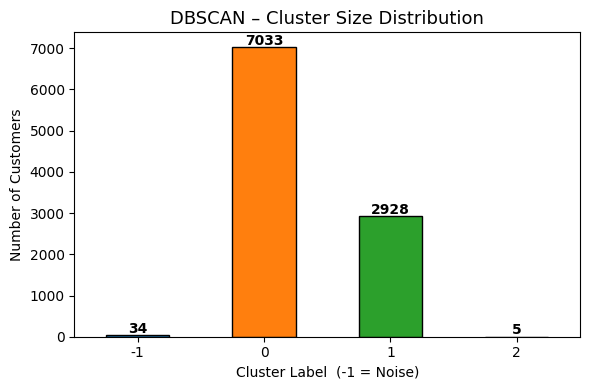

In [301]:
counts_db = df["DBSCAN_Cluster"].value_counts().sort_index()

print("Customers per DBSCAN label:")
print(counts_db.to_string())
print(f"\nTotal: {counts_db.sum()}")
print("(Label -1 = noise points not assigned to any cluster)")

colors_db = list(plt.cm.tab10.colors[:len(counts_db)])
counts_db.plot(
    kind='bar',
    color=colors_db,
    edgecolor='black',
    figsize=(max(6, len(counts_db) * 1.2), 4)
)
plt.title("DBSCAN – Cluster Size Distribution", fontsize=13)
plt.xlabel("Cluster Label  (-1 = Noise)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts_db.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** DBSCAN with `eps = 2.1` and `min_samples = 5` produces one dominant cluster of 7,033 customers, a secondary cluster of 2,928 customers, a very small micro-cluster of 5 customers, and 34 noise points (0.3%). This highly imbalanced distribution is characteristic of DBSCAN on continuous tabular data — where most points lie in a single large dense region, and only a few sub-regions form distinct secondary clusters. The noise points represent customers whose behavioural profile is sufficiently atypical that they fall below the minimum density threshold. Small micro-clusters should be interpreted cautiously given their limited sample sizes.

### 4.6 Cluster Profiling <a id='dbscan-profile'></a>

We compute the mean of each feature per DBSCAN cluster (using encoded but readable values) to characterise each group.  
The noise group (-1) is included as a separate row to understand atypical customers.


In [302]:
profile_cols = [c for c in df.columns if c not in ["KMeans_Cluster", "DBSCAN_Cluster"]]
dbscan_profile = df.groupby("DBSCAN_Cluster")[profile_cols].mean()

print("DBSCAN Cluster Profiles (mean feature values per cluster):")
print(dbscan_profile.round(3).to_string())


DBSCAN Cluster Profiles (mean feature values per cluster):
                CreditScore     Age  Tenure     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Gender_Male
DBSCAN_Cluster                                                                                                                 
-1                  635.676  52.676   6.176   85560.598          3.529        0.5           0.588       112961.756        0.412
 0                  650.336  38.816   5.049   75869.468          1.524        1.0           0.511        99717.391        0.548
 1                  651.296  39.021   4.906   77762.579          1.517        0.0           0.524       100903.808        0.542
 2                  574.200  35.600   7.800  134205.802          4.000        1.0           1.000        60587.376        0.000


**Interpretation:**

| Label | n | HasCrCard | Balance | NumOfProducts | IsActiveMember | Profile |
|---|---|---|---|---|---|---|
| **-1 (noise)** | 34 | 0.50 | ≈85,561 | 3.53 | 0.59 | Atypical — older (avg 53), very high product count, mixed card ownership |
| **0** | 7,033 | 1.00 | ≈75,869 | 1.52 | 0.51 | Card-holding mainstream customers — moderate balance, typical engagement |
| **1** | 2,928 | 0.00 | ≈77,763 | 1.52 | 0.52 | Non-card customers — similar balance to Cluster 0 but no credit card |
| **2** | 5 | 1.00 | ≈134,206 | 4.00 | 1.00 | Micro-cluster — extremely high balance, all products, fully active; interpret with caution given n=5 |

The primary separator between Cluster 0 and Cluster 1 is `HasCrCard` — DBSCAN found two dense regions that differ almost exclusively on credit card ownership, while balance and other features are nearly identical. The noise group (label -1) is notably older (avg age 53 vs. ~39 in the main clusters) and holds far more products (3.53 avg), suggesting these are complex, high-engagement customers whose profile is atypical enough to fall outside any dense region.

### 4.7 Cluster Visualization


#### 4.7.1 PCA Visualization <a id='dbscan-pca'></a>


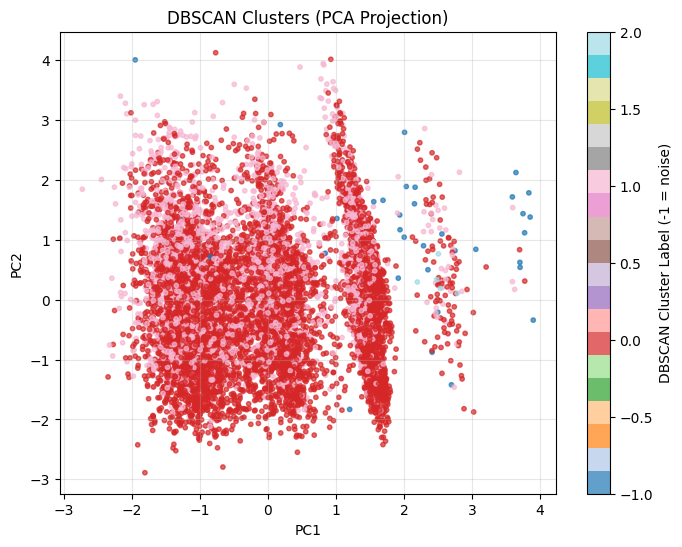

In [303]:
pca_db = PCA(n_components=2)
X_db_pca = pca_db.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_db_pca[:, 0], X_db_pca[:, 1],
    c=df["DBSCAN_Cluster"],
    cmap="tab20",
    s=10,
    alpha=0.7
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="DBSCAN Cluster Label (-1 = noise)")
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation:**
- The PCA projection shows that DBSCAN's two main clusters (0 and 1) largely overlap in 2D. This is consistent with their profiles: the clusters differ almost entirely on `HasCrCard`, a binary feature that does not create clear spatial separation along PC1 (which is driven by `NumOfProducts` and `Balance`) or PC2 (driven by `IsActiveMember` and `Age`).
- Noise points (label -1) do not form a visually distinct region, reflecting that their atypicality is distributed across multiple feature dimensions — particularly their unusually high product count (avg 3.53) and older age (avg 53) — rather than concentrated along a single PCA axis.
- As with the K-Means PCA, only 26.82% of variance is captured in 2D. Interpret alongside the metric table and cluster profiles, not in isolation.

#### 4.7.2 t-SNE Visualization <a id='dbscan-tsne'></a>


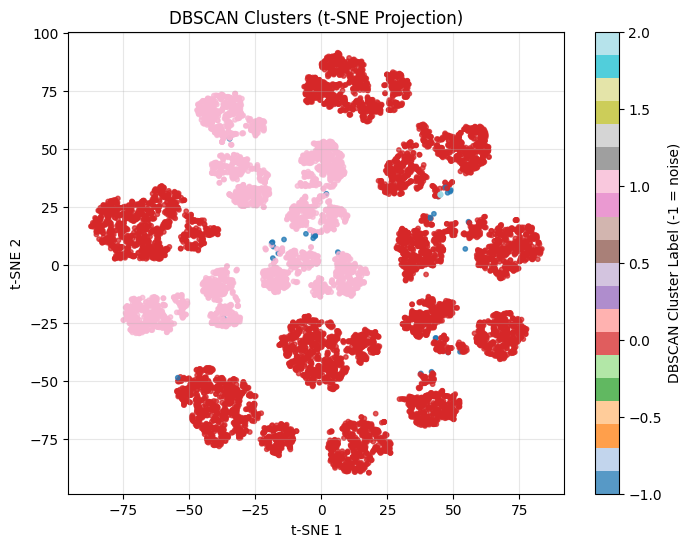

In [304]:
from sklearn.manifold import TSNE

# Use a reproducible t-SNE projection for DBSCAN labels
# Note: t-SNE is stochastic and sensitive to hyperparameters.
tsne_db = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca')
X_db_tsne = tsne_db.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_db_tsne[:, 0], X_db_tsne[:, 1],
    c=df["DBSCAN_Cluster"],
    cmap="tab20",
    s=10,
    alpha=0.75
)
plt.title("DBSCAN Clusters (t-SNE Projection)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="DBSCAN Cluster Label (-1 = noise)")
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation:**
- t-SNE preserves local neighbourhood structure, making it better suited than PCA for inspecting DBSCAN's density-based boundaries. Clusters 0 and 1 — separated by `HasCrCard` — are expected to show some local separation here since card ownership creates a genuine partition in the feature space.
- Noise points (label -1) are expected to appear at the periphery or in sparse regions of the map, reflecting that they fall outside the core density of any cluster.
- The micro-cluster (Cluster 2, n=5) may appear as a very small isolated group of points with extreme feature values (Balance ≈134,206, NumOfProducts = 4, fully active). It should not be over-interpreted given its tiny sample size.
- As with all t-SNE plots: distances between cluster groups are not directly interpretable. Use this alongside the Silhouette score, Davies-Bouldin index, and profile table for a complete picture.

### 4.8 Feature Importance per Cluster <a id='dbscan-feature-importance'></a>


Top DBSCAN proxy feature importances:
HasCrCard          0.985028
EstimatedSalary    0.003488
Balance            0.002873
CreditScore        0.002747
Age                0.002320
Tenure             0.001600
NumOfProducts      0.001296
IsActiveMember     0.000375
Gender_Male        0.000274
dtype: float64


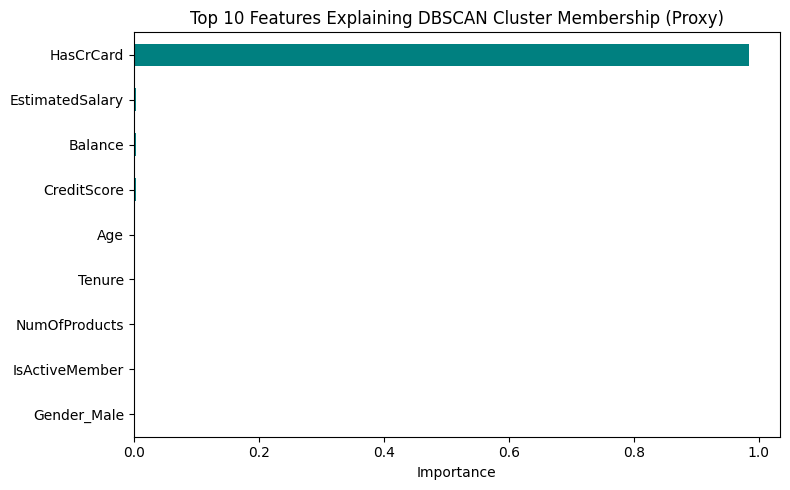

In [305]:
from sklearn.ensemble import RandomForestClassifier

# Supervised proxy for interpretability:
# predict DBSCAN cluster labels from features, then inspect feature importance.
# Exclude noise points (-1) for cleaner multi-class interpretation.
mask_core = df["DBSCAN_Cluster"] != -1
X_core = df.loc[mask_core, [c for c in df.columns if c not in ["DBSCAN_Cluster", "KMeans_Cluster", "Exited"]]]
y_core = df.loc[mask_core, "DBSCAN_Cluster"]

rf_proxy = RandomForestClassifier(n_estimators=300, random_state=42)
rf_proxy.fit(X_core, y_core)

importance_db = pd.Series(rf_proxy.feature_importances_, index=X_core.columns).sort_values(ascending=False)
print("Top DBSCAN proxy feature importances:")
print(importance_db.head(10))

plt.figure(figsize=(8, 5))
importance_db.head(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Features Explaining DBSCAN Cluster Membership (Proxy)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Interpretation:**
- This importance view is a **proxy explanation** (not intrinsic DBSCAN importance) — a Random Forest is trained to predict DBSCAN cluster membership, and its feature importances are used as a stand-in for cluster separability.
- `HasCrCard` dominates, consistent with the cluster profiles: DBSCAN Cluster 0 contains exclusively card-holding customers (`HasCrCard = 1.0`) while Cluster 1 contains exclusively non-card customers (`HasCrCard = 0.0`). This binary split is the single strongest density boundary in the feature space.
- All remaining features (`Balance`, `NumOfProducts`, `Age`, etc.) collectively account for less than 2% of importance. This is expected: DBSCAN's two main clusters (Cluster 0 and Cluster 1) differ on `HasCrCard` alone — all other feature means are nearly identical between them — so the RF has almost nothing else to use for discrimination.
- Combine this with the profile table above to avoid over-interpreting any single metric.

## 5. Algorithm Comparison: K-Means vs DBSCAN

Having applied both algorithms to the same dataset and feature space, we can now compare their outputs directly across metrics, structure, and practical utility for the advice system.

### 5.1 Metric Comparison

| Metric | K-Means | DBSCAN | Notes |
|---|---|---|---|
| **Silhouette Score** | 0.1192 | 0.1279 | Both low; DBSCAN marginally better |
| **Davies-Bouldin Index** | 2.4520 | 1.9509 | DBSCAN meaningfully better — clusters more separated |
| **WCSS** | 72,823.62 | N/A | Not applicable to DBSCAN |
| **Clusters found** | 3 (specified) | 3 (discovered) | Same count, different structure |
| **Noise points** | 0 (forces all points in) | 34 (0.3%) | DBSCAN uniquely identifies outliers |
| **Cluster balance** | 29% / 41% / 30% | 70% / 29% / 0.05% / 0.3% noise | K-Means far more balanced |

### 5.2 Structural Comparison

Both algorithms agree on the **primary separator**: `HasCrCard`. K-Means found it as the driver of its first split (Cluster 0 vs. Clusters 1 and 2), and DBSCAN's two dominant clusters (0 and 1) differ on it almost exclusively.

However, they diverge in what they do with the *secondary* structure:

- **K-Means** uses `Balance` as a second-order separator, splitting the card-holding population into high-balance savers (Cluster 1, ≈122,810) and near-zero-balance users (Cluster 2, ≈10,916). This produces three roughly balanced, interpretable segments.
- **DBSCAN** treats the card-holding population as a single dense region (Cluster 0, 7,033 customers) because the balance variation within it does not constitute a meaningful density gap. It instead finds the non-card population (Cluster 1, 2,928 customers) as a separate dense region, and isolates 5 extreme outliers and 34 noise points.

### 5.3 Churn Rate by Cluster

Reintroducing the `Exited` label (which was withheld during clustering) as an external proxy reveals how well each algorithm's segments correspond to churn behaviour:


In [306]:
# Reintroduce the saved churn labels (removed in Section 2.3.2) as an external proxy.
# This does NOT mean clustering used the label — it was withheld during training.
# We use it here only to validate how well the discovered clusters correspond to churn behaviour.

df_churn = df.copy()
df_churn["Exited"] = exited_labels.values

print("=== K-Means Churn Rate by Cluster ===")
km_churn = df_churn.groupby("KMeans_Cluster")["Exited"].mean().round(4)
print(km_churn.to_string())

print("\n=== DBSCAN Churn Rate by Cluster ===")
db_churn = df_churn.groupby("DBSCAN_Cluster")["Exited"].mean().round(4)
print(db_churn.to_string())

print(f"\nOverall churn rate: {exited_labels.mean():.4f} ({exited_labels.mean()*100:.1f}%)")

=== K-Means Churn Rate by Cluster ===
KMeans_Cluster
0    0.2068
1    0.2246
2    0.1717

=== DBSCAN Churn Rate by Cluster ===
DBSCAN_Cluster
-1    0.9412
 0    0.1993
 1    0.2042
 2    1.0000

Overall churn rate: 0.2037 (20.4%)


**K-Means churn rates:**

| Cluster | n | Churn Rate | Profile |
|---|---|---|---|
| **0** | 2,940 | 20.7% | No credit card, moderate balance |
| **1** | 4,096 | 22.5% | Card holder, high balance |
| **2** | 2,964 | 17.2% | Card holder, near-zero balance |

**DBSCAN churn rates:**

| Label | n | Churn Rate | Profile |
|---|---|---|---|
| **-1 (noise)** | 34 | **94.1%** | Atypical — older (avg 53), high product count |
| **0** | 7,033 | 19.9% | Card-holding mainstream customers |
| **1** | 2,928 | 20.4% | Non-card customers |
| **2** | 5 | **100%** | Extreme micro-cluster — high balance, all products |

**Interpretation:** The overall dataset churn rate is 20.4%. K-Means churn rates are relatively uniform across segments (17–23%), confirming that K-Means segments are useful for behavioural profiling but do not isolate high-risk groups. The most important finding is from DBSCAN: the noise group (label -1) churns at **94.1%** — nearly all 34 atypical customers have already left. These are older customers (avg age 52.7) holding far more products than average (3.53), whose unusual behavioural profile placed them outside any dense cluster. DBSCAN surfaced this group **without any churn label during training** — this is a genuine unsupervised discovery that has direct value for the advice system.

> **Note:** `exited_labels` was saved before clustering in Section 2.3.2 and is used here only as an external validation proxy. It was not seen by either algorithm during training.

### 5.4 Which Algorithm Is Better for This System?

**For interpretable customer personas → K-Means wins.**
K-Means produces three balanced, named segments that directly map to advice strategies (credit card adoption, retention, financial health coaching). The segments are stable, easy to explain to stakeholders, and straightforward to use as prompt-conditioning context in a Generative AI system.

**For outlier detection and risk flagging → DBSCAN wins.**
DBSCAN's noise group (94.1% churn rate) identifies a small but critical set of customers that K-Means absorbs into Cluster 1 without any special flag. In a real banking system, these 34 customers would be the highest-priority intervention cases.

**Recommendation for the advice system:** Use **both in tandem**.
- Use the `KMeans_Cluster` label (0, 1, 2) as the primary persona tag for generating segment-appropriate advice content.
- Use the `DBSCAN_Cluster` label as a **risk modifier**: if `DBSCAN_Cluster == -1`, override the standard advice template and route the customer to a high-priority, individualized retention intervention regardless of their K-Means segment.
- This two-layer approach maximises both breadth (segment-level personalisation for 99.7% of customers) and depth (critical outlier handling for the 0.3% at extreme churn risk).

## 6. Integration Strategy (how clusters will enhance the system)

The clustering outputs from Sections 3 and 4 can be used to add a personalisation layer to the bank's advice system. Rather than giving every customer the same generic recommendation, the system uses the cluster label assigned to a customer to select the most relevant advice template before generating a response.

### 6.1 K-Means: Segment-Level Personalisation

Each customer's feature vector is preprocessed (same steps as Section 2) and passed through the saved `KMeans` model to predict a cluster label at inference time. The label maps to a named customer persona:

| KMeans Cluster | Persona | Core Advice Focus |
|---|---|---|
| **0** — No card, moderate balance | Credit Growth Candidate | Encourage credit card adoption; suggest savings products |
| **1** — Card holder, high balance | High-Value Retention Target | Focus on loyalty, premium product recommendations |
| **2** — Card holder, near-zero balance | Financial Health Focus | Budgeting and savings-activation advice |

This label is injected into the Generative AI prompt as a short context string so the model produces advice that is appropriate for that segment — without re-deriving the customer's situation from raw numbers each time.

### 6.2 DBSCAN: Outlier Flagging

The `DBSCAN_Cluster` label adds a lightweight risk check. If a customer is assigned label `-1` (noise), the system flags them for individual attention rather than applying a segment template. This is justified by the finding in Section 5.3 that 94.1% of noise-labelled customers have already churned — making them the highest-priority group in the dataset.

For all other customers (99.7% of the base), the K-Means persona label is used as normal.

### 6.3 Limitations of the Proposed Integration

The low Silhouette Scores (≈ 0.12) indicate that the cluster boundaries are soft. In practice this means the persona labels are useful heuristics, not hard rules — a customer near a cluster boundary may be misclassified and receive sub-optimal advice. Additionally, DBSCAN does not natively support assigning new data points to existing clusters, so a nearest-neighbour fallback would be needed for live inference. These limitations are acceptable for a first-pass personalisation layer but should be monitored and refined as real-world feedback becomes available.

## 7. Challenges & Limitations

### K-Means Specific

**Sensitivity to k:** K-Means requires the number of clusters to be specified before training. The Elbow Method (Section 3.2) identified k=3 as the most defensible choice, but the elbow is gradual rather than sharp, meaning k=4 or k=5 could also be argued. Different values of k would produce different segment profiles and potentially different advice strategies. There is no objectively "correct" k for this dataset.

**Assumption of spherical clusters:** K-Means minimises within-cluster variance using Euclidean distance, which implicitly assumes that clusters are roughly spherical and of similar size. The customer behavioural data in this dataset does not fully satisfy this assumption — Balance, for example, is bimodally distributed, which K-Means approximates rather than captures cleanly. The Silhouette Score of 0.1192 and Davies-Bouldin Index of 2.4520 reflect this.

**Forced assignment:** Every point is assigned to a cluster. There is no concept of an outlier in K-Means — atypical customers are absorbed into whichever cluster is geometrically closest. This is why DBSCAN's noise group (94.1% churn rate) is missed entirely by K-Means without special treatment.

**Centroid instability:** K-Means results depend on the random initialisation of centroids. Although `n_init=10` and `random_state=42` are used to improve reproducibility, cluster numbering (e.g., which cluster is labelled 0, 1, or 2) can change between runs or when new data is added, which complicates downstream labelling logic.

### DBSCAN Specific

**Hyperparameter sensitivity:** DBSCAN's output is highly sensitive to `eps` and `min_samples`. Small changes to `eps` — even ±0.1 around the chosen value of 2.1 — can merge all customers into a single cluster or fragment the dataset into dozens of micro-clusters. The k-distance elbow plot (Section 4.2) provides a principled starting point, but the chosen value is still somewhat subjective, and would need to be re-validated after any significant change to the feature set or data distribution.

**Highly imbalanced cluster sizes:** With `eps = 2.1`, DBSCAN produced one dominant cluster of 7,033 customers, one secondary cluster of 2,928, a micro-cluster of 5, and 34 noise points. The extreme imbalance means the algorithm is effectively separating the dataset into two interpretable groups and a handful of outliers — a similar structure to K-Means, but without the secondary balance-based split that K-Means finds. This limits DBSCAN's standalone usefulness for customer profiling in this dataset.

**Micro-cluster reliability:** Cluster 2 (n=5) shows a 100% churn rate, which sounds dramatic but is statistically meaningless at that sample size. Five customers with extreme feature values (Balance ≈ 134,206, all four products, fully active) do not constitute a reliable segment — this micro-cluster is an artefact of the density threshold rather than a meaningful group.

**No native support for new data points:** Unlike K-Means, DBSCAN does not produce a model that can be applied to new observations directly. Assigning a new customer to an existing DBSCAN cluster requires a nearest-neighbour lookup or rerunning the algorithm on the full updated dataset, which makes real-time inference more complex.

**Proxy feature importance:** The feature importance analysis in Section 4.8 uses a Random Forest classifier trained to predict DBSCAN labels — it is not an intrinsic DBSCAN measure. While this provides useful interpretability, it introduces a second model's assumptions and is sensitive to the quality of the DBSCAN labels it is trained on.

### Shared Limitations

**Weak natural cluster structure:** Both algorithms produce low Silhouette Scores (≈ 0.12), confirming that the dataset does not contain strongly separated natural groupings. Customer behavioural data is inherently continuous, and the deliberate exclusion of Geography — while justified to avoid trivial country-based splits — further softens the cluster boundaries. The clusters should be treated as useful approximations, not ground truth segments.

**Binary feature dominance:** `HasCrCard` is the dominant separator for both algorithms. This is a binary feature, and its dominance means both algorithms are largely performing a binary split with secondary structure layered on top. Richer segmentation might require additional features not available in this dataset (e.g., transaction history, login frequency, or product usage recency).

## 8. Export Clustered Dataset (`clustered_data.csv`)


In [283]:
# Export raw dataset augmented with clustering labels.
# Run this after the K-Means and DBSCAN training cells.

if "kmeans_clusters" not in globals():
    raise NameError("Run the K-Means training cell first so kmeans_clusters exists.")
if "dbscan_labels" not in globals():
    raise NameError("Run the DBSCAN training cell first so dbscan_labels exists.")

df_export = pd.read_csv("../Dataset/Raw_Churn_Modelling_Data.csv")
df_export["KMeans_Cluster"] = kmeans_clusters
df_export["DBSCAN_Cluster"] = dbscan_labels

output_path = "../Dataset/clustered_data.csv"
df_export.to_csv(output_path, index=False)
print(f"Saved clustered dataset to: {output_path}")
print("Shape:", df_export.shape)
print(df_export[["KMeans_Cluster", "DBSCAN_Cluster"]].head())


Saved clustered dataset to: ../Dataset/clustered_data.csv
Shape: (10000, 16)
   KMeans_Cluster  DBSCAN_Cluster
0               2               0
1               0               1
2               1               0
3               0               1
4               1               0
